# 3.6.softmax回归的从零开始实现

就像我们从零开始实现线性回归一样，我们认为softmax回归也是重要的基础，因此应该知道实现softmax回归的细节。本节我们将使用刚刚在 [<span style="color: #ffbf00; font-weight: bold;"> 3.5节 </span>](./03.05_image_classification_dataset.ipynb)中引入的Fashion-MNIST数据集，并设置数据迭代器的批量大小为256。


本节中涉及反向传播算子的实现，但读者不必完全理解反向算子的推导，因为本节重点是前向计算与训练流程，只需知道反向的输入输出即可。

---

## 环境准备

In [ ]:
%pip install pypto==0.2.0 torch torch_npu numpy

In [ ]:
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"

import torch
import torchvision
from torch import nn
from torch.utils import data
from torchvision import transforms
from IPython import display
import matplotlib.pyplot as plt
import pypto

from src.D2LFunction import *

然后加载数据集。

In [4]:
batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)

---

## 3.6.1.初始化模型参数

和之前线性回归的例子一样，这里的每个样本都将用固定长度的向量表示。原始数据集中的每个样本都是$28 \times 28$的图像。本节将展平每个图像，把它们看作长度为784的向量。在后面的章节中，我们将讨论能够利用图像空间结构的特征，但现在我们暂时只把每个像素位置看作一个特征。

回想一下，在softmax回归中，我们的输出与类别一样多。因为我们的数据集有10个类别，所以网络输出维度为10。因此，权重将构成一个$784 \times 10$的矩阵，偏置将构成一个$1 \times 10$的行向量。与线性回归一样，我们将使用正态分布初始化我们的权重`W`，偏置初始化为0。


In [5]:
num_inputs = 784
num_outputs = 10

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), device='npu:0', requires_grad=True)
b = torch.zeros(num_outputs, device='npu:0', requires_grad=True)

---

## 3.6.2.定义softmax操作

在实现softmax回归模型之前，我们简要回顾一下`sum`运算符如何沿着张量中的特定维度工作。如 [<span style="color: #ffbf00; font-weight: bold;"> 2.3.6节 </span>](../02_pypto_preliminaries/02.03_linear_algebra.ipynb)和 [<span style="color: #ffbf00; font-weight: bold;"> 2.3.6.1节 </span>](../02_pypto_preliminaries/02.03_linear_algebra.ipynb)所述， 给定一个矩阵`X`，我们可以对任意一个轴上的元素进行求和，即同一列（轴0）或同一行（轴1）。 如果`X`是一个形状为`(2, 3)`的张量，我们对列进行求和， 则结果将是一个具有形状`(3,)`的向量。 当调用`sum`运算符时，我们可以指定保持在原始张量的轴数，而不折叠求和的维度。 这将产生一个具有形状`(1, 3)`的二维张量。


In [ ]:
@pypto.frontend.jit()
def sum_kernel(
    x: pypto.Tensor([], pypto.DT_FP32),
    sum_cols: pypto.Tensor([], pypto.DT_FP32),
    sum_rows: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(8, 8)
    sum_cols[:] = pypto.sum(x, dim=0, keepdim=True)
    sum_rows[:] = pypto.sum(x, dim=1, keepdim=True)

X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]], device='npu:0')
sum_cols = torch.empty([1, 3], device='npu:0')
sum_rows = torch.empty([2, 1], device='npu:0')
sum_kernel(X, sum_cols, sum_rows)
print(sum_cols, '\n', sum_rows)

tensor([[5., 7., 9.]], device='npu:0') 
 tensor([[ 6.],
        [15.]], device='npu:0')


<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <p style="margin: 0 0 10px 0;">在实现 softmax 回归模型之前，我们简要回顾一下 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">sum</code> 运算符如何沿着张量中的特定维度工作。如 2.3.6 节和 2.3.6.1 节所述，给定一个矩阵 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">X</code>，我们可以对所有元素求和（默认情况下）。也可以只求同一个轴上的元素，即同一列（轴 0）或同一行（轴 1）。如果 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">X</code> 是一个形状为 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">(2, 3)</code> 的张量，我们对列进行求和，则结果将是一个具有形状 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">(3,)</code> 的向量。当调用 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">sum</code> 运算符时，我们可以指定保持在原始张量的轴数，而不折叠求和的维度。这将产生一个具有形状 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">(1, 3)</code> 的二维张量。</p>
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X.sum(0, keepdim=True), X.sum(1, keepdim=True)</pre>
    <pre><span style="color: #1f2937; font-family: Consolas, monospace; font-size: 13px;">(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))</span></pre>
  </div>
</details>

回想一下，实现softmax由三个步骤组成：

1. 对每个项求幂（使用`exp`）；
2. 对每一行求和（小批量中每个样本是一行），得到每个样本的规范化常数；
3. 将每一行除以其规范化常数，确保结果的和为1。

在查看代码之前，我们回顾一下这个表达式：

$$
\mathrm{softmax}(\mathbf{X})_{ij} = \frac{\exp(\mathbf{X}_{ij})}{\sum_k \exp(\mathbf{X}_{ik})}.\tag{3.6.1}
$$

分母或规范化常数，有时也称为*配分函数*（其对数称为对数-配分函数）。该名称来自[统计物理学](https://en.wikipedia.org/wiki/Partition_function_(statistical_mechanics))中一个模拟粒子群分布的方程。


$$
\begin{array}{c|c}
 & \text{softmax} \\ \hline
\text{前向} & y = \dfrac{e^{x}}{\sum_k e^{x_k}} \\ \hline
\text{反向} & \dfrac{\partial L}{\partial x} = y \odot \bigl(g - \sum(g \odot y)\bigr)
\end{array}
$$

In [ ]:
@pypto.frontend.jit()
def softmax_kernel(
    x: pypto.Tensor([], pypto.DT_FP32),
    out: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(8, 8)
    x_exp = pypto.exp(x)
    partition = pypto.sum(x_exp, dim=-1, keepdim=True)
    out[:] = x_exp / partition

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0; font-family: Consolas, monospace;">def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition</pre>
  </div>
</details>

正如上述代码，对于任何随机输入，我们将每个元素变成一个非负数。此外，依据概率原理，每行总和为1。


In [ ]:
X = torch.normal(0, 1, (2, 5), device='npu:0')
X_prob = torch.empty_like(X)
softmax_kernel(X, X_prob)
print(X_prob, '\n', X_prob.sum(1))

tensor([[0.2331, 0.1171, 0.5045, 0.0732, 0.0721],
        [0.0064, 0.0539, 0.7862, 0.0140, 0.1394]], device='npu:0')
 tensor([1.0000, 1.0000], device='npu:0')


<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">X = torch.normal(0, 1, (2, 5))
X_prob = softmax(X)
X_prob, X_prob.sum(1)</pre>
    <pre><span style="color: #1f2937; font-family: Consolas, monospace; font-size: 13px;">(tensor([[0.1686, 0.4055, 0.0849, 0.1064, 0.2347],
         [0.0217, 0.2652, 0.6354, 0.0457, 0.0321]]),
 tensor([1.0000, 1.0000]))</span></pre>
  </div>
</details>

注意，虽然这在数学上看起来是正确的，但我们在代码实现中有点草率。矩阵中的非常大或非常小的元素可能造成数值上溢或下溢，但我们没有采取措施来防止这点。

与[<span style="color: #ffbf00; font-weight: bold;"> 3.2节 </span>](./03.02_linear_regression_scratch.ipynb)类似，我们也需要定义 `softmax` 的反向算子并接入 PyTorch 框架。

In [9]:
@pypto.frontend.jit()
def softmax_backward_kernel(
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    y: pypto.Tensor([], pypto.DT_FP32),
    grad_x: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(16, 16)
    grad_x[:] = y * (grad_out - pypto.sum(grad_out * y, dim=-1, keepdim=True))

class PyPTOSoftmaxFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        x_c = x.contiguous()
        out = torch.empty_like(x_c)
        softmax_kernel(x_c, out)
        ctx.save_for_backward(out)
        return out

    @staticmethod
    def backward(ctx, grad_out):
        (y,) = ctx.saved_tensors
        grad_x = torch.empty_like(y)
        softmax_backward_kernel(grad_out.contiguous(), y, grad_x)
        return grad_x

---

## 3.6.3.定义模型

定义 `softmax` 操作后，我们可以实现 softmax 回归模型。softmax 回归模型其本质为一个线性模型加一个 `softmax` 操作，因而，我们需要先定义一个线性模型。

In [ ]:
@pypto.frontend.jit()
def linear_forward_kernel(
    X: pypto.Tensor([], pypto.DT_FP32),
    W: pypto.Tensor([], pypto.DT_FP32),
    b_2d: pypto.Tensor([], pypto.DT_FP32),
    out: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_cube_tile_shapes([32, 32], [64, 64], [64, 64])
    out[:] = pypto.matmul(X, W, pypto.DT_FP32,
                          extend_params={'bias_tensor': b_2d})

@pypto.frontend.jit()
def linear_backward_kernel(
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    X: pypto.Tensor([], pypto.DT_FP32),
    W: pypto.Tensor([], pypto.DT_FP32),
    grad_X: pypto.Tensor([], pypto.DT_FP32),
    grad_W: pypto.Tensor([], pypto.DT_FP32),
    grad_b_2d: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_cube_tile_shapes([32, 32], [64, 64], [64, 64])
    grad_X[:] = pypto.matmul(grad_out, W, pypto.DT_FP32, b_trans=True)
    grad_W[:] = pypto.matmul(X, grad_out, pypto.DT_FP32, a_trans=True)
    pypto.set_vec_tile_shapes(16, 16)
    grad_b_2d[:] = pypto.sum(grad_out, dim=0, keepdim=True)

class PyPTOLinearFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, X, W, b):
        X_c, W_c = X.contiguous(), W.contiguous()
        b_2d = b.contiguous().view(1, -1)
        out = torch.empty((X.shape[0], W.shape[1]), dtype=X.dtype, device=X.device)
        linear_forward_kernel(X_c, W_c, b_2d, out)
        ctx.save_for_backward(X_c, W_c)
        return out

    @staticmethod
    def backward(ctx, grad_out):
        X, W = ctx.saved_tensors
        grad_out_c = grad_out.contiguous()
        grad_X = torch.empty_like(X)
        grad_W = torch.empty_like(W)
        grad_b_2d = torch.empty((1, W.shape[1]), dtype=W.dtype, device=W.device)
        linear_backward_kernel(grad_out_c, X, W, grad_X, grad_W, grad_b_2d)
        grad_b = grad_b_2d.view(-1)
        return grad_X, grad_W, grad_b

<details class="code-note" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠代码说明</summary>
  <div class="code-note-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <ul style="margin: 0; padding-left: 20px;">
        <li style="margin: 0 0 8px 0;">前向中将 1 维的 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">b</code> 转为 2 维的 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">b_2d</code> 再传入 kernel 的原因是：</li>
        <p style="margin: 0 0 10px 0;">为了通过 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">pypto.matmul</code> 的 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">extend_params={'bias_tensor': b_2d}</code> 将偏置加法融合到矩阵乘中，避免 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">matmul + bias</code> 的两次访存与算子调度开销，速度更快；该接口要求偏置是 2 维的 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">(1, num_outputs)</code>，因此在 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">forward</code> 中通过 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">b.contiguous().view(1, -1)</code> 完成 reshape。</p>
        <li style="margin: 0 0 8px 0;">反向中沿用 2 维 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">grad_b_2d</code> 的原因是：</li>
        <p style="margin: 0;"><code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">pypto.sum(grad_out, dim=0, keepdim=True)</code> 自然得到形状为 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">(1, num_outputs)</code> 的 2 维张量，保留 2 维形态便于在 kernel 中与前向的 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">b_2d</code> 保持一致；最后再通过 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">grad_b_2d.view(-1)</code> 压回 1 维以匹配原参数 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">b</code> 的形状参与更新。</p>
    </ul>
  </div>
</details>

下面的代码定义了输入如何通过网络映射到输出。注意，将数据传递到模型之前，我们使用`reshape`函数将每张原始图像展平为向量。

In [11]:
def net(X):
    return PyPTOSoftmaxFunction.apply(
        PyPTOLinearFunction.apply(X.reshape((-1, W.shape[0])), W, b)
    )

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0; font-family: Consolas, monospace;">def net(X):
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)</pre>
  </div>
</details>

---

## 3.6.4.定义损失函数

接下来，我们实现 [<span style="color: #ffbf00; font-weight: bold;"> 3.4节 </span>](./03.04_softmax_regression.ipynb)中引入的交叉熵损失函数。这可能是深度学习中最常见的损失函数，因为目前分类问题的数量远远超过回归问题的数量。

$$
\begin{array}{c|c}
 & \text{交叉熵} \\ \hline
\text{前向} & L = -\log \hat{y}_{[i,\,y]} \\ \hline
\text{反向} & \dfrac{\partial L}{\partial \hat{y}} = -\dfrac{g}{\hat{y}_{[i,y]}} \odot \mathrm{one\_hot}(y)
\end{array}
$$

回顾一下，交叉熵采用真实标签的预测概率的负对数似然。这里我们不使用Python的for循环迭代预测（这往往是低效的），而是通过一个运算符选择所有元素。下面，我们创建一个数据样本`y_hat`，其中包含2个样本在3个类别的预测概率，以及它们对应的标签`y`。有了`y`，我们知道在第一个样本中，第一类是正确的预测；而在第二个样本中，第三类是正确的预测。然后使用`y`作为`y_hat`中概率的索引，我们选择第一个样本中第一个类的概率和第二个样本中第三个类的概率。

In [12]:
y = torch.tensor([0, 2], device='npu:0')
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]], device='npu:0')
y_hat[[0, 1], y]

tensor([0.1000, 0.5000], device='npu:0')

同上文一样，我们为交叉熵定义正向和反向算子，然后接入 PyTorch 框架。

In [ ]:
@pypto.frontend.jit()
def cross_entropy_forward_kernel(
    y_hat: pypto.Tensor([], pypto.DT_FP32),
    y_1d: pypto.Tensor([], pypto.DT_INT32),
    out: pypto.Tensor([], pypto.DT_FP32),
    num_classes: int,
):
    y_2d = pypto.reshape(y_1d, [-1, 1])
    pypto.set_vec_tile_shapes(8, ((num_classes + 7) // 8) * 8)
    selected = pypto.gather(y_hat, -1, y_2d)
    out[:] = pypto.neg(pypto.log(selected))

@pypto.frontend.jit()
def cross_entropy_backward_kernel(
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    y_hat: pypto.Tensor([], pypto.DT_FP32),
    y_1d: pypto.Tensor([], pypto.DT_INT32),
    grad_y_hat: pypto.Tensor([], pypto.DT_FP32),
    num_classes: int,
):
    y_2d = pypto.reshape(y_1d, [-1, 1])
    pypto.set_vec_tile_shapes(8, ((num_classes + 7) // 8) * 8)
    selected = pypto.gather(y_hat, -1, y_2d)
    pypto.set_vec_tile_shapes(8, num_classes)
    one_hot_y = pypto.cast(pypto.one_hot(y_1d, num_classes), pypto.DT_FP32)
    pypto.set_vec_tile_shapes(8, 8)
    grad_y_hat[:] = -(grad_out / selected) * one_hot_y

class PyPTOCrossEntropyFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, y_hat, y, num_classes):
        y_hat_c = y_hat.contiguous()
        y_i32_1d = y.to(torch.int32).contiguous()
        out = torch.empty((y_hat.shape[0], 1), dtype=y_hat.dtype, device=y_hat.device)
        cross_entropy_forward_kernel(y_hat_c, y_i32_1d, out, num_classes)
        ctx.save_for_backward(y_hat, y_i32_1d)
        ctx.num_classes = num_classes
        return out.view(-1)

    @staticmethod
    def backward(ctx, grad_out):
        y_hat, y_i32_1d = ctx.saved_tensors
        grad_out_c = grad_out.view(-1, 1).contiguous()
        grad_y_hat = torch.empty_like(y_hat)
        cross_entropy_backward_kernel(
            grad_out_c, y_hat, y_i32_1d, grad_y_hat, ctx.num_classes
        )
        return grad_y_hat, None, None

def cross_entropy(y_hat, y):
    return PyPTOCrossEntropyFunction.apply(y_hat, y, y_hat.shape[1])

cross_entropy(y_hat, y)

tensor([2.3026, 0.6931], device='npu:0')

<details class="code-note" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠代码说明</summary>
  <div class="code-note-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <ul style="margin: 0; padding-left: 20px;">
      <li style="margin: 0 0 8px 0;">前向算子中 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">pypto.gather(y_hat, 1, y)</code> 的作用是：</li>
      <p style="margin: 0 0 10px 0;">
        <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">pypto.gather</code> 是 PyPTO 的索引选取算子，沿指定 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">dim</code> 根据 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">index</code> 张量从 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">input</code> 中抽取对应位置的元素，输出形状与 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">index</code> 相同。在本例中它按真实标签 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">y</code> 的索引，从预测概率 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">y_hat</code> 中挑出每个样本对应类别的预测概率，用于后续计算 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">-log(picked)</code> 作为交叉熵损失。
      </p>
      <li style="margin: 0 0 8px 0;">反向算子中 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">pypto.one_hot(y, num_classes)</code> 的作用是：</li>
      <p style="margin: 0 0 10px 0;">
        <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">pypto.one_hot</code> 是 PyPTO 的独热编码算子，把整数类别索引张量转换为在指定索引处为 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">1</code>、其余为 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">0</code> 的多分类标签张量。在本例中它将真实标签 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">y</code> 转为形状 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">(batch, num_classes)</code> 的 one-hot 矩阵，便于与 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">softmax(y_hat)</code> 逐元素相减，得到交叉熵对 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">y_hat</code> 的梯度。
      </p>
      <li style="margin: 0 0 8px 0;">前向算子中 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">set_vec_tile_shapes(8, ((num_classes + 7) // 8) * 8)</code> 的作用是：</li>
      <p style="margin: 0 0 10px 0;">
        这一步是为 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">pypto.gather</code> 设置合适的 TileShape。
        其中，尾轴长度 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">((num_classes + 7) // 8) * 8</code> 有两个目的：
      </p>
      <p style="margin: 0 0 10px 0;">
        ① 覆盖范围足够：根据 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">gather</code> 文档，gather 轴对应的 TileShape 长度需要大于等于该轴实际参与计算的长度。本例中 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">y_hat</code> 的最后一维长度为 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">num_classes</code>，因此 tile 的尾轴至少要覆盖到 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">num_classes</code>。
      </p>
      <p style="margin: 0 0 10px 0;">
        ② 满足对齐要求：向量算子的尾轴需要满足 32 字节对齐。这里按 8 的倍数向上取整，是为了让尾轴长度满足这一对齐约束。
      </p>
      <li style="margin: 0 0 8px 0;">反向算子中多次调用 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">set_vec_tile_shapes</code> 的原因是：</li>
      <p style="margin: 0 0 10px 0;">
        反向传播里依次用了多个算子，而不同算子对 TileShape 的要求不同，所以需要在算子切换前重新设置。
      </p>
      <p style="margin: 0 0 10px 0;">
        ① <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">(8, ((num_classes + 7) // 8) * 8)</code>：用于 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">gather</code>，要求与前向一致，既能覆盖最后一维长度，又满足尾轴对齐。
      </p>
      <p style="margin: 0 0 10px 0;">
        ② <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">(8, num_classes)</code>：用于 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">one_hot</code>，因为该算子要求 TileShape 的尾轴必须严格等于 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">num_classes</code>。
      </p>
      <p style="margin: 0;">
        ③ <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">(8, 8)</code>：用于后续逐元素计算，主要目的是把 TileShape 切回一个满足尾轴 32 字节对齐的通用设置。
      </p>
    </ul>
  </div>
</details>

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <p style="margin: 0 0 10px 0;">现在我们只需一行代码就可以实现交叉熵损失函数。</p>
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">def cross_entropy(y_hat, y):
    return - torch.log(y_hat[range(len(y_hat)), y])
cross_entropy(y_hat, y)</pre>
    <span style="color: #1f2937; font-family: Consolas, monospace; font-size: 13px;">tensor([2.3026, 0.6931])</span>
  </div>
</details>

---

## 3.6.5.分类精度

给定预测概率分布`y_hat`，当我们必须输出硬预测（hard prediction）时，我们通常选择预测概率最高的类。许多应用都要求我们做出选择。如Gmail必须将电子邮件分类为“Primary（主要邮件）”、“Social（社交邮件）”“Updates（更新邮件）”或“Forums（论坛邮件）”。Gmail做分类时可能在内部估计概率，但最终它必须在类中选择一个。

当预测与标签分类`y`一致时，即是正确的。分类精度即正确预测数量与总预测数量之比。虽然直接优化精度可能很困难（因为精度的计算不可导），但精度通常是我们最关心的性能衡量标准，我们在训练分类器时几乎总会关注它。

为了计算精度，我们执行以下操作。首先，如果`y_hat`是矩阵，那么假定第二个维度存储每个类的预测分数。我们使用 `pypto.topk` 沿最后一个维度取最大元素的索引来获得预测类别。然后将预测类别与真实 y 元素逐元素比较，并把布尔比较结果通过 `pypto.where` 转为包含 0（错）和 1（对）的张量。最后，在第 0 维上对该张量求和，便得到正确预测的数量。


In [14]:
@pypto.frontend.jit()
def accuracy_kernel(
    y_hat: pypto.Tensor([], pypto.DT_FP32),
    y: pypto.Tensor([], pypto.DT_INT64),
    correct: pypto.Tensor([], pypto.DT_FP32)
):
    pypto.set_vec_tile_shapes(16, 16)
    res = pypto.topk(y_hat, 1, -1, True)
    argmax_i32 = res[1] 

    argmax_f32 = pypto.cast(argmax_i32, pypto.DT_FP32)
    y_f32      = pypto.cast(pypto.reshape(y, [-1, 1]), pypto.DT_FP32)
    cmp        = pypto.eq(argmax_f32, y_f32)
    cmp_num    = pypto.where(cmp, 1.0, 0.0)
    
    total      = pypto.sum(cmp_num, dim=0, keepdim=False)
    correct[:] = total

def accuracy(y_hat, y):
    """计算预测正确的数量"""
    correct = torch.empty((1,), dtype=torch.float32, device=y_hat.device)
    accuracy_kernel(y_hat.contiguous(), y.contiguous(), correct)
    return float(correct.item())

<details class="code-note" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠代码说明</summary>
  <div class="code-note-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <ul style="margin: 0; padding-left: 20px;">
      <li style="margin: 0 0 8px 0;"><code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">pypto.topk</code> 的作用是：</li>
      <p style="margin: 0 0 10px 0;">
        <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">pypto.topk(y_hat, 1, -1, True)</code> 会沿最后一个维度取最大值及其索引，返回的 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">res[1]</code> 就是预测类别索引，作用等价于 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">argmax</code>。之所以这样写，是因为 PyPTO 0.2.0 还没有提供 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">argmax</code> 算子。
      </p>
      <li style="margin: 0 0 8px 0;">为什么要先 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">cast</code> 再比较：</li>
      <p style="margin: 0 0 10px 0;">
        因为 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">pypto.eq</code> 只支持浮点类型，不支持整型。这里预测索引是 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">INT32</code>，标签是 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">INT64</code>，所以要先都转成 fp32，再做相等比较。
      </p>
      <li style="margin: 0 0 8px 0;">为什么用 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">where</code>：</li>
      <p style="margin: 0 0 10px 0;">
        因为 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">pypto.eq</code> 的输出是 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">DT_BOOL</code>，而 PyPTO 0.2.0 的 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">cast</code> 不支持把它直接转成数值类型。所以这里用 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">pypto.where(cmp, 1.0, 0.0)</code>，把 True/False 变成 1.0/0.0 的 fp32 张量。
      </p>
      <li style="margin: 0 0 8px 0;">为什么最后再做 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">sum</code>：</li>
      <p style="margin: 0;">
        因为 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">pypto.sum</code> 只支持 fp32 输入。前一步通过 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">where</code> 得到 0/1 的 fp32 张量后，就可以在批量维上求和，得到整批样本中预测正确的数量。
      </p>
    </ul>
  </div>
</details>

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <p style="margin: 0 0 10px 0;">为了计算精度，我们执行以下操作。首先，如果 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">y_hat</code> 是矩阵，那么假定第二个维度存储每个类的预测分数。我们使用 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">argmax</code> 获得每行中最大元素的索引来获得预测类别。然后我们将预测类别与真实 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">y</code> 元素进行比较。由于等式运算符“<code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">==</code>”对数据类型很敏感，因此我们将 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">y_hat</code> 的数据类型转换为与 <code style="font-family: Consolas, monospace; background-color: #f3f4f6; padding: 2px 5px; border-radius: 3px; color: #1f2937; font-size: 13px;">y</code> 的数据类型一致。结果是一个包含 0（错）和 1（对）的张量。最后，我们求和会得到正确预测的数量。</p>
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0; font-family: Consolas, monospace;">def accuracy(y_hat, y):
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())</pre>
  </div>
</details>

我们将继续使用之前定义的变量`y_hat`和`y`分别作为预测的概率分布和标签。可以看到，第一个样本的预测类别是2（该行的最大元素为0.6，索引为2），这与实际标签0不一致。第二个样本的预测类别是2（该行的最大元素为0.5，索引为2），这与实际标签2一致。因此，这两个样本的分类精度率为0.5。


In [15]:
accuracy(y_hat, y) / len(y)

0.5

同样，对于任意数据迭代器`data_iter`可访问的数据集，我们可以评估在任意模型`net`的精度。


In [16]:
def evaluate_accuracy(net, data_iter):
    """计算在指定数据集上模型的精度"""
    if isinstance(net, torch.nn.Module):
        net.eval()  # 将模型设置为评估模式
    metric = Accumulator(2)  # 正确预测数、预测总数
    with torch.no_grad():
        for X, y in data_iter:
            X = X.npu()
            y = y.npu()
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

这里定义一个实用程序类`Accumulator`，用于对多个变量进行累加。在上面的`evaluate_accuracy`函数中，我们在`Accumulator`实例中创建了2个变量，分别用于存储正确预测的数量和预测的总数量。当我们遍历数据集时，两者都将随着时间的推移而累加。


In [17]:
class Accumulator:
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

由于我们使用随机权重初始化`net`模型，因此该模型的精度应接近于随机猜测。例如在有10个类别情况下的精度为0.1。


In [18]:
evaluate_accuracy(net, test_iter)

0.0994

---

## 3.6.6.训练

在我们看过 [<span style="color: #ffbf00; font-weight: bold;"> 3.2节 </span>](./03.02_linear_regression_scratch.ipynb)中的线性回归实现，softmax回归的训练过程代码应该看起来非常眼熟。在这里，我们重构训练过程的实现以使其可重复使用。首先，我们定义一个函数来训练一个迭代周期。请注意，`updater`是更新模型参数的常用函数，它接受批量大小作为参数。它可以是`d2l.sgd`函数，也可以是框架的内置优化函数。


In [19]:
def train_epoch_ch3(net, train_iter, loss, updater):
    """训练模型一个迭代周期（定义见第3章）"""
    # 将模型设置为训练模式
    if isinstance(net, torch.nn.Module):
        net.train()
    # 训练损失总和、训练准确度总和、样本数
    metric = Accumulator(3)
    for X, y in train_iter:
        X = X.npu()
        y = y.npu()
        # 计算梯度并更新参数
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            # 使用PyTorch内置的优化器和损失函数
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            # 使用定制的优化器和损失函数
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    # 返回训练损失和训练精度
    return metric[0] / metric[2], metric[1] / metric[2]

在展示训练函数的实现之前，我们定义一个在动画中绘制数据的实用程序类`Animator`，它能够简化本书其余部分的代码。


In [20]:
class Animator:
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

接下来我们实现一个训练函数，它会在`train_iter`访问到的训练数据集上训练一个模型`net`。该训练函数将会运行多个迭代周期（由`num_epochs`指定）。在每个迭代周期结束时，利用`test_iter`访问到的测试数据集对模型进行评估。我们将利用`Animator`类来可视化训练进度。


In [21]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    """训练模型（定义见第3章）"""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

作为一个从零开始的实现，我们使用 [<span style="color: #ffbf00; font-weight: bold;"> 3.2节 </span>](./03.02_linear_regression_scratch.ipynb)中定义的小批量随机梯度下降来优化模型的损失函数，设置学习率为0.1。


In [22]:
lr = 0.1

def updater(batch_size):
    return sgd([W, b], lr, batch_size)

现在，我们训练模型10个迭代周期。请注意，迭代周期（`num_epochs`）和学习率（`lr`）都是可调节的超参数。通过更改它们的值，我们可以提高模型的分类精度。


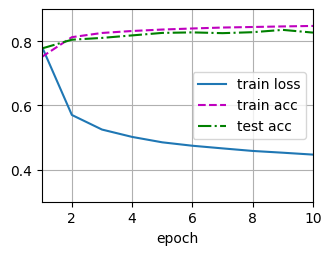

In [23]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

---

## 3.6.7.预测

现在训练已经完成，我们的模型已经准备好对图像进行分类预测。给定一系列图像，我们将比较它们的实际标签（文本输出的第一行）和模型预测（文本输出的第二行）。


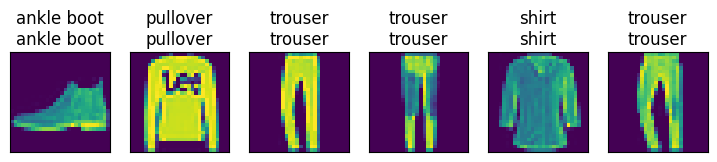

In [24]:
def predict_ch3(net, test_iter, n=6):  #@save
    """预测标签（定义见第3章）"""
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(net(X.npu()).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    show_images(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])

predict_ch3(net, test_iter)

---

## 3.6.8.小结

* 借助softmax回归，我们可以训练多分类的模型。
* 训练softmax回归循环模型与训练线性回归模型非常相似：先读取数据，再定义模型和损失函数，然后使用优化算法训练模型。大多数常见的深度学习模型都有类似的训练过程。


---

## 3.6.9.练习

1. 本节直接实现了基于数学定义softmax运算的`softmax`函数。这可能会导致什么问题？提示：尝试计算$\exp(50)$的大小。
2. 本节中的函数`cross_entropy`是根据交叉熵损失函数的定义实现的。它可能有什么问题？提示：考虑对数的定义域。
3. 请想一个解决方案来解决上述两个问题。
4. 返回概率最大的分类标签总是最优解吗？例如，医疗诊断场景下可以这样做吗？
5. 假设我们使用softmax回归来预测下一个单词，可选取的单词数目过多可能会带来哪些问题?


详细参考答案见 [answers/03.06_reference_answer](./answers/03.06_reference_answer.ipynb)。

#### 参考答案（PyPTO）

In [ ]:
!cat answers/txt/03.06_reference_answer_pypto.txt

#### 参考答案（PyTorch）

In [ ]:
!cat answers/txt/03.06_reference_answer_pytorch.txt